## Notebook for reading in baseline files, computing the 75th percentile temps, saving it out

In [16]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt
import dask
import dask.array as da
import xarray as xr
from dask.diagnostics import ProgressBar
from dask.utils import format_bytes

In [8]:
#import sys
#!conda install --yes --prefix {sys.prefix} dask

In [2]:
file_path = '../../../Data/ERA5-global/Baseline/*/*.nc'

# open without dask chunking and see if it crashes
#ds = xr.open_mfdataset(file_path) #, chunks={'time': 10})

# can't do quantile calc unless we are chunked
ds = xr.open_mfdataset(file_path, chunks={'latitude': 10, 'longitude': 10})

In [3]:
ds.nbytes

7587489832

In [4]:
ds

<xarray.Dataset> Size: 8GB
Dimensions:      (time: 1827, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 15kB 1960-01-01 1960-01-02 ... 1990-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 8GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-08T18:20 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [6]:
# load it into memory because I can't do quantile on on the dask dataset (also can't figure out how to do percentile)
ds.load()

<xarray.Dataset> Size: 8GB
Dimensions:      (time: 1827, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 15kB 1960-01-01 1960-01-02 ... 1990-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 8GB 245.6 245.6 245.6 ... 254.4 254.4
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-08T18:20 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [7]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75 = ds.t2m.quantile(0.75, dim=('time'))
c_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
c_75.attrs["units"] = "K"
c_75

CPU times: user 37.9 s, sys: 1.34 s, total: 39.3 s
Wall time: 39.7 s


<xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 8MB
array([[236.46439362, 236.46439362, 236.46439362, ..., 236.46439362,
        236.46439362, 236.46439362],
       [236.23018646, 236.23233795, 236.23441315, ..., 236.22354889,
        236.22566986, 236.2278595 ],
       [235.74856567, 235.75222778, 235.75584412, ..., 235.73815155,
        235.74160767, 235.74510956],
       ...,
       [271.34170532, 271.34068298, 271.33950806, ..., 271.34519958,
        271.34414673, 271.34292603],
       [271.3210144 , 271.32043457, 271.32023621, ..., 271.32215881,
        271.32194519, 271.32138062],
       [271.31929016, 271.31929016, 271.31929016, ..., 271.31929016,
        271.31929016, 271.31929016]])
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

### assuming everything looks good, then the next cell writes it out

In [12]:
#'../../../Data/ERA5-global/Baseline/*/*.nc'
c_75.to_netcdf("../../../Data/ERA5-global/Baseline/computed_1960-1990_75th.nc")

### and hopfully this closes the objects to free up memory

In [13]:
ds.close()
c_75.close()

In [14]:
! ls -l "../../../Data/ERA5-global/Baseline/"

total 16280
drwxr-xr-x@ 14 tedscott  staff      448 Jun 14 14:36 1960
drwxr-xr-x@ 13 tedscott  staff      416 Jun 14 14:36 1970
drwxr-xr-x@ 15 tedscott  staff      480 Jun 14 14:36 1979
drwxr-xr-x@ 14 tedscott  staff      448 Jun  4 10:57 1980
drwxr-xr-x@ 14 tedscott  staff      448 Jun 14 14:37 1990
-rw-r--r--   1 tedscott  staff  8334967 Jun 14 16:31 computed_1960-1990_75th.nc


Text(0.5, 1.0, '75th Percentile T2m from 1960,1970,1979,1980,1990')

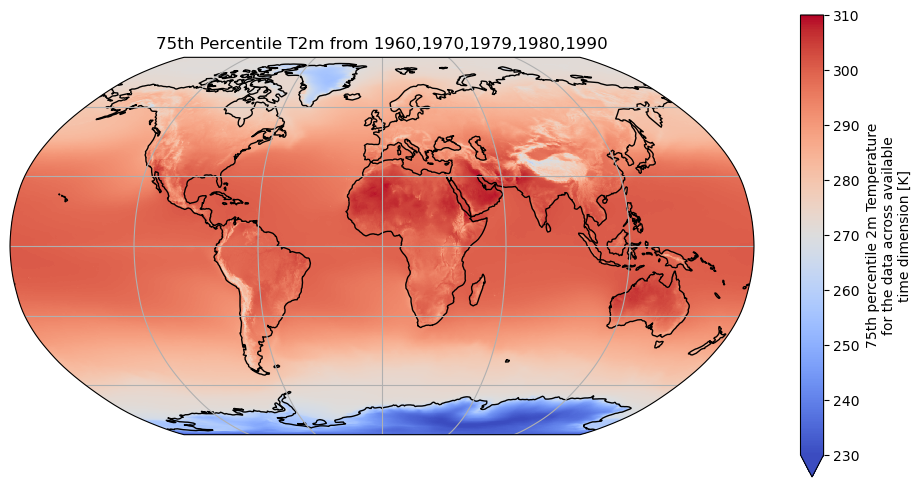

In [17]:
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

# plot first index of SSTs
c_75.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=230,
    vmax=310, # define temp range for colorbar 230 to 310 K
    cmap="coolwarm"
)

plt.title("75th Percentile T2m from 1960,1970,1979,1980,1990")